In [3]:
# %% [markdown]
# ## 1. Imports & Setup

# %%
import re
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize

# Register tqdm with pandas
tqdm.pandas()
warnings.filterwarnings('ignore')

# Download required NLTK data for tokenization
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    print("Downloading NLTK punkt and punkt_tab tokenizers...")
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True) # <-- This is the newly required package

Loading data from D:\project\NLP\data\processed\dialogues_with_emotion.csv...
Loaded 204 lines of dialogue.
Extracting lexical features (this may take a moment)...


  0%|          | 0/204 [00:00<?, ?it/s]

Saving enriched dataset to D:\project\NLP\data\processed\dialogues_with_features.csv...
Save complete!


,Movie,Scene,Character,Dialogue,Sentiment_Score,Sentiment_Label,Emotion_Label,Word_Count,Sentence_Count,Words_Per_Sentence,Lexical_Diversity_TTR,Hesitation_Markers,Is_Question
0,AMERICAN_PSYCHO,INT. 'PASTELS' RESTAURANT - NIGHT,BATEMAN V/O,...with goat cheese profiteroles and i also ha...,0.6868,Positive,Neutral,180,13,13.846154,0.661111,4,1
1,AMERICAN_PSYCHO,INT. 'PASTELS' RESTAURANT - NIGHT,MCDERMOTT,you'll notice that my friends and i all look a...,0.4644,Positive,Anger,170,16,10.625000,0.594118,1,1
2,AMERICAN_PSYCHO,INT. 'PASTELS' RESTAURANT - NIGHT,MCDERMOTT,you think so? you'll look like you consciously...,0.7370,Positive,Sadness,167,21,7.952381,0.592814,0,1
3,AMERICAN_PSYCHO,INT. 'PASTELS' RESTAURANT - NIGHT,MCDERMOTT,that s paul owen. that's not paul owen. paul o...,0.8496,Positive,Surprise,112,15,7.466667,0.571429,0,1
4,AMERICAN_PSYCHO,INT. 'PASTELS' RESTAURANT - NIGHT,VAN PATTEN,"you spin a dreidel, mcdermott, not a menorah. ...",0.8594,Positive,Neutral,113,15,7.533333,0.601770,1,1


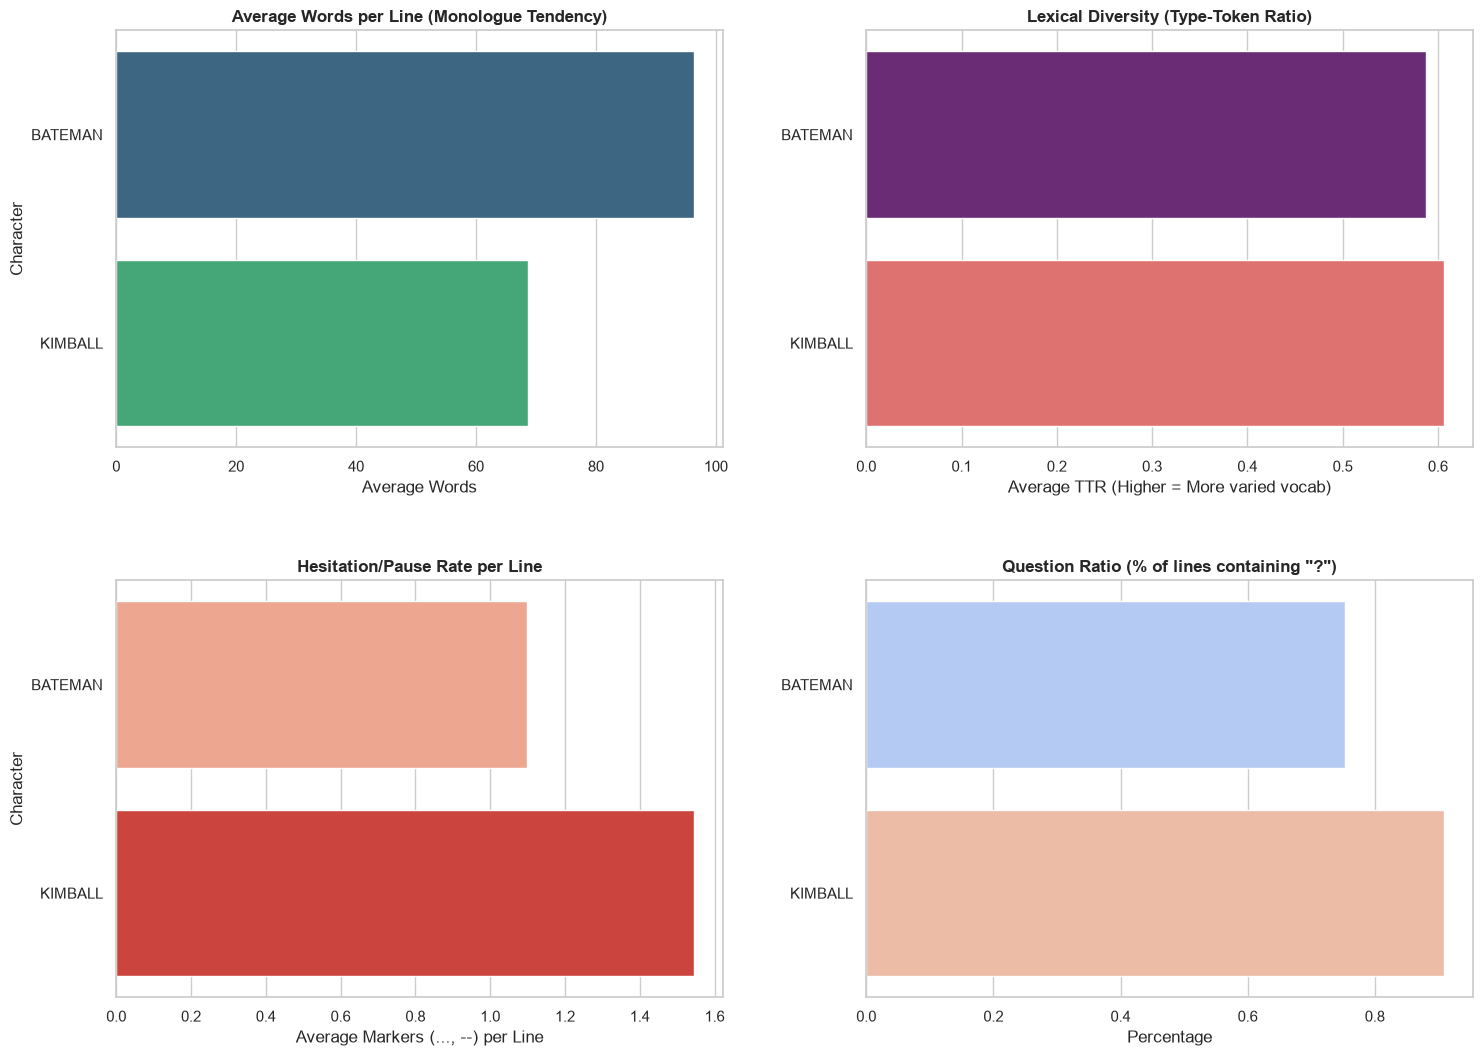

COMMUNICATION STYLE INSIGHTS
Longest Monologues (Avg):      BATEMAN (96.4 words/line)
Most Repetitive Speech (TTR):  BATEMAN
Highest Hesitation/Pause Rate: KIMBALL
Most Inquisitive (Questions):  KIMBALL (90.9% of lines)


In [4]:
# %% [markdown]
# # 03 - Communication Style & Lexical Features
# **Project:** AI-Based Media Empathy Analyzer  
# **Objective:** Extract linguistic features (lexical diversity, sentence complexity, hesitation markers) to profile character communication styles, a vital step for evaluating neurodivergent representation.

# %% [markdown]
# ## 1. Imports & Setup

# %%
import re
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize

# Register tqdm with pandas
tqdm.pandas()
warnings.filterwarnings('ignore')

# Download required NLTK data for tokenization
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("Downloading NLTK punkt tokenizer...")
    nltk.download('punkt', quiet=True)

# %% [markdown]
# ## 2. Configuration

# %%
# Define base directory
BASE_DIR = Path(r"D:\project\NLP")

# Input and Output paths
PROCESSED_DATA_DIR = BASE_DIR / "data" / "processed"
INPUT_FILE = PROCESSED_DATA_DIR / "dialogues_with_emotion.csv"
OUTPUT_FILE = PROCESSED_DATA_DIR / "dialogues_with_features.csv"

# Ensure directory exists
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

# %% [markdown]
# ## 3. Loading Data

# %%
print(f"Loading data from {INPUT_FILE}...")
if not INPUT_FILE.exists():
    raise FileNotFoundError(f"Cannot find {INPUT_FILE}. Please run Notebook 02 first.")

df = pd.read_csv(INPUT_FILE)
df.dropna(subset=['Dialogue'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Loaded {len(df)} lines of dialogue.")

# %% [markdown]
# ## 4. Feature Extraction Functions
# We are building features that represent *how* a character speaks, which is critical for identifying different cognitive and communication styles.

# %%
def extract_lexical_features(text: str) -> dict:
    """
    Analyzes a block of dialogue to extract communication style features.
    
    Args:
        text (str): Cleaned dialogue string.
        
    Returns:
        dict: Dictionary containing calculated linguistic features.
    """
    # Tokenize into words and sentences
    words = word_tokenize(str(text))
    sentences = sent_tokenize(str(text))
    
    word_count = len(words)
    sentence_count = len(sentences) if len(sentences) > 0 else 1
    
    # 1. Lexical Diversity (Type-Token Ratio)
    # Measures vocabulary richness. Lower TTR can indicate repetitive speech.
    unique_words = set(w.lower() for w in words if w.isalnum())
    ttr = len(unique_words) / word_count if word_count > 0 else 0
    
    # 2. Complexity
    words_per_sentence = word_count / sentence_count
    
    # 3. Pragmatic Markers (Hesitations, Pauses, Interruptions)
    # Screenplays use ellipses (...) or em-dashes (--) for pauses, trailing off, or being cut off.
    hesitation_markers = len(re.findall(r'\.\.\.|--', str(text)))
    
    # 4. Questioning vs. Declarative
    # How often does this line contain a question mark?
    contains_question = 1 if '?' in str(text) else 0
    
    return {
        'Word_Count': word_count,
        'Sentence_Count': sentence_count,
        'Words_Per_Sentence': words_per_sentence,
        'Lexical_Diversity_TTR': ttr,
        'Hesitation_Markers': hesitation_markers,
        'Is_Question': contains_question
    }

# %% [markdown]
# ## 5. Applying Feature Extraction

# %%
print("Extracting lexical features (this may take a moment)...")

# Apply extraction function and expand into columns
features_series = df['Dialogue'].progress_apply(extract_lexical_features)
features_df = pd.DataFrame(features_series.tolist())

# Concatenate back to main dataframe
df = pd.concat([df, features_df], axis=1)

# %% [markdown]
# ## 6. Saving Enriched Dataset

# %%
print(f"Saving enriched dataset to {OUTPUT_FILE}...")
df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8')
print("Save complete!")

display(df.head(5))

# %% [markdown]
# ## 7. Character Communication Profiling (EDA)
# Let's aggregate these features to build a "Communication Profile" for our top characters.

# %%
# Filter for characters with at least 15 lines of dialogue to ensure statistical relevance
char_counts = df['Character'].value_counts()
valid_chars = char_counts[char_counts >= 15].index
profile_df = df[df['Character'].isin(valid_chars)]

# Group by Character to get their average speaking style
char_profiles = profile_df.groupby('Character').agg({
    'Word_Count': 'mean',                  # Average monologue length
    'Lexical_Diversity_TTR': 'mean',       # Average vocabulary richness per line
    'Hesitation_Markers': 'sum',           # Total times they hesitated/paused
    'Is_Question': 'mean',                 # % of lines that are questions
    'Dialogue': 'count'                    # Total lines spoken
}).rename(columns={'Dialogue': 'Total_Lines'})

# Sort by Total Lines for relevance
char_profiles = char_profiles.sort_values(by='Total_Lines', ascending=False).head(15)

# Setup Visualizations
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.tight_layout(pad=6.0)

# Plot 1: Average Words per Line (Monologue Tendency)
sns.barplot(
    x=char_profiles['Word_Count'], 
    y=char_profiles.index, 
    palette='viridis', 
    ax=axes[0, 0]
)
axes[0, 0].set_title('Average Words per Line (Monologue Tendency)', fontweight='bold')
axes[0, 0].set_xlabel('Average Words')
axes[0, 0].set_ylabel('Character')

# Plot 2: Lexical Diversity (Repetitive vs Rich Speech)
sns.barplot(
    x=char_profiles['Lexical_Diversity_TTR'], 
    y=char_profiles.index, 
    palette='magma', 
    ax=axes[0, 1]
)
axes[0, 1].set_title('Lexical Diversity (Type-Token Ratio)', fontweight='bold')
axes[0, 1].set_xlabel('Average TTR (Higher = More varied vocab)')
axes[0, 1].set_ylabel('')

# Plot 3: Hesitation Markers (Anxiety/Masking/Pauses)
# Normalize hesitations by total lines to get a rate
char_profiles['Hesitation_Rate'] = char_profiles['Hesitation_Markers'] / char_profiles['Total_Lines']
sns.barplot(
    x=char_profiles['Hesitation_Rate'], 
    y=char_profiles.index, 
    palette='Reds', 
    ax=axes[1, 0]
)
axes[1, 0].set_title('Hesitation/Pause Rate per Line', fontweight='bold')
axes[1, 0].set_xlabel('Average Markers (..., --) per Line')
axes[1, 0].set_ylabel('Character')

# Plot 4: Question Ratio (Directness / Inquisitiveness)
sns.barplot(
    x=char_profiles['Is_Question'], 
    y=char_profiles.index, 
    palette='coolwarm', 
    ax=axes[1, 1]
)
axes[1, 1].set_title('Question Ratio (% of lines containing "?")', fontweight='bold')
axes[1, 1].set_xlabel('Percentage')
axes[1, 1].set_ylabel('')

plt.show()

# %% [markdown]
# ## 8. Insight Generation

# %%
print("="*60)
print("COMMUNICATION STYLE INSIGHTS")
print("="*60)

# Identify extreme communicators
longest_speaker = char_profiles['Word_Count'].idxmax()
most_repetitive = char_profiles['Lexical_Diversity_TTR'].idxmin()
most_hesitant = char_profiles['Hesitation_Rate'].idxmax()
most_inquisitive = char_profiles['Is_Question'].idxmax()

print(f"Longest Monologues (Avg):      {longest_speaker} ({char_profiles.loc[longest_speaker, 'Word_Count']:.1f} words/line)")
print(f"Most Repetitive Speech (TTR):  {most_repetitive}")
print(f"Highest Hesitation/Pause Rate: {most_hesitant}")
print(f"Most Inquisitive (Questions):  {most_inquisitive} ({char_profiles.loc[most_inquisitive, 'Is_Question']*100:.1f}% of lines)")
print("="*60)